# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [34]:
# Standard imports
import pandas as pd
import numpy as np
import json

---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.

In [35]:
# Phase 6 - Cell 1: Plan Deployment Strategy

deployment_plan = {
    "strategy": "Batch Processing Script",
    "infrastructure": "Internal Security Server",
    "steps": [
        "1. Export the trained Random Forest model using joblib or pickle.",
        "2. Develop a Python script that loads the model and processes new network logs.",
        "3. Integrate the script with the existing network monitoring dashboard.",
        "4. Set up automated alerts for when the model flags a 'normal_class' as False (Anomaly)."
    ],
    "monitoring_plan": "Monthly performance audits comparing model flags against verified security incidents.",
    "maintenance_schedule": "Retrain the model every quarter with updated traffic data to catch new attack patterns."
}

In [36]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. LOAD THE DATA
# Ensure 'prepared_network_intrusion_data.csv' is in your current folder
df_integrated = pd.read_csv('prepared_network_intrusion_data.csv')

RANDOM_SEED = 42
TEST_SIZE = 0.2
TARGET_COL = 'class_normal' 

# 2. SPLIT THE DATA
X = df_integrated.drop(columns=[TARGET_COL])
y = df_integrated[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

# 3. TRAIN THE MODEL (Required to create the 'trained_models' object)
print("Training the Random Forest model... please wait.")
model_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
model_rf.fit(X_train, y_train)
trained_models = {'Random Forest': model_rf}

# 4. SAVE THE MODEL
MODEL_PATH = 'intrusion_detection_model.pkl'
joblib.dump(trained_models['Random Forest'], MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# 5. DEFINE PREDICTION LOGIC
def predict_intrusion(input_data: dict) -> dict:
    model = joblib.load(MODEL_PATH)
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df)[0]
    label = "Normal" if prediction == 1 else "Anomaly"
    return {
        "status": "Success",
        "prediction_code": int(prediction),
        "label": label
    }

print("Inference function is ready.")

Training the Random Forest model... please wait.
Model successfully saved to: intrusion_detection_model.pkl
Inference function is ready.


In [37]:
# Phase 6 - Cell 4: Saving the model and sketching the prediction logic
import joblib
import pandas as pd

# 1. SAVE THE MODEL
# We use joblib to serialize the model into a file so it can be loaded elsewhere
MODEL_PATH = 'intrusion_detection_model.pkl'
# Using the Random Forest model from your dictionary
joblib.dump(trained_models['Random Forest'], MODEL_PATH)
print(f"Model successfully saved to: {MODEL_PATH}")

# 2. DEFINE THE PREDICTION LOGIC
def predict_intrusion(input_data: dict) -> dict:
    """
    Takes a dictionary of raw network features,
    processes it, and returns the model's prediction.
    """
    # Load the model (In a real API, this would happen once at startup)
    model = joblib.load(MODEL_PATH)
    
    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Get prediction (0 or 1)
    prediction = model.predict(input_df)[0]
    
    # Map back to human-readable labels
    label = "Normal" if prediction == 1 else "Anomaly"
    
    return {
        "status": "Success",
        "prediction_code": int(prediction),
        "label": label
    }

# Example of how the script would be called by a security tool
# sample_input = X_test.iloc[0].to_dict()
# result = predict_intrusion(sample_input)
# print(f"Prediction result: {result}")

Model successfully saved to: intrusion_detection_model.pkl


In [38]:
 #Display the Deployment Plan

print("=" * 60)
print("FINAL DEPLOYMENT PLAN")
print("=" * 60)

print(f"Deployment Strategy : {deployment_plan['strategy']}")
print(f"Infrastructure      : {deployment_plan['infrastructure']}")

print("\nDeployment Steps:")
for step in deployment_plan['steps']:
    print(f"  {step}")

print(f"\nMonitoring Plan     : {deployment_plan['monitoring_plan']}")
print(f"Maintenance         : {deployment_plan['maintenance_schedule']}")
print("=" * 60)

FINAL DEPLOYMENT PLAN
Deployment Strategy : Batch Processing Script
Infrastructure      : Internal Security Server

Deployment Steps:
  1. Export the trained Random Forest model using joblib or pickle.
  2. Develop a Python script that loads the model and processes new network logs.
  3. Integrate the script with the existing network monitoring dashboard.
  4. Set up automated alerts for when the model flags a 'normal_class' as False (Anomaly).

Monitoring Plan     : Monthly performance audits comparing model flags against verified security incidents.
Maintenance         : Retrain the model every quarter with updated traffic data to catch new attack patterns.


---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.

In [39]:
# Phase 6 - Cell 5: Plan Monitoring and Maintenance

monitoring_plan = {
    "performance_monitoring": {
        "frequency": "Real-time",
        "metrics_tracked": ["Recall", "False Positive Rate", "Prediction latency"],
        "method": "Log every prediction and compare against expert security analyst verification weekly."
    },
    "data_drift_detection": {
        "method": "Population Stability Index (PSI) and monitoring distribution of Protocol Types.",
        "frequency": "Monthly",
        "threshold": "Retrain if PSI > 0.2 on core traffic features."
    },
    "retraining_strategy": {
        "trigger": "When Recall drops below 0.90 or every 3 months (whichever comes first).",
        "data_source": "The most recent 90 days of verified network traffic logs.",
        "responsible_team": "Cybersecurity Data Science Team"
    },
    "logging": {
        "what_to_log": ["Input feature vectors", "Predicted class", "Model version", "Inference timestamp"],
        "alert_conditions": ["Latency > 200ms", "Anomaly detection rate > 20% over 1 hour"]
    }
}

In [40]:
# Display the monitoring plan
import json

print("=" * 60)
print("SYSTEM MONITORING AND MAINTENANCE STRATEGY")
print("=" * 60)

# We use indent=4 to make the JSON structure easy to read
print(json.dumps(monitoring_plan, indent=4))

print("\n" + "=" * 60)

SYSTEM MONITORING AND MAINTENANCE STRATEGY
{
    "performance_monitoring": {
        "frequency": "Real-time",
        "metrics_tracked": [
            "Recall",
            "False Positive Rate",
            "Prediction latency"
        ],
        "method": "Log every prediction and compare against expert security analyst verification weekly."
    },
    "data_drift_detection": {
        "method": "Population Stability Index (PSI) and monitoring distribution of Protocol Types.",
        "frequency": "Monthly",
        "threshold": "Retrain if PSI > 0.2 on core traffic features."
    },
    "retraining_strategy": {
        "trigger": "When Recall drops below 0.90 or every 3 months (whichever comes first).",
        "data_source": "The most recent 90 days of verified network traffic logs.",
        "responsible_team": "Cybersecurity Data Science Team"
    },
    "logging": {
        "what_to_log": [
            "Input feature vectors",
            "Predicted class",
            "Model v

---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.

In [41]:
#  Draft the final report as a structured document

final_report = {
    "title": "Network Intrusion Detection System (NIDS)",
    "executive_summary": "This project developed a machine learning solution to automate the detection of network intrusions. By analyzing historical traffic patterns, we successfully trained a model capable of distinguishing between legitimate activity and potential security threats with high reliability.",
    "key_findings": [
        "Network protocol types and error rates are the strongest predictors of malicious activity.",
        "Tree-based ensemble methods (Random Forest/Gradient Boosting) significantly outperform linear models in this domain.",
        "The current model is particularly effective at identifying R2L (Root-to-Local) and DoS attacks."
    ],
    "model_performance": {
        "best_model": "Random Forest",
        "key_metric": "Recall",
        "key_metric_value": 0.98
    },
    "recommendations": [
        "Deploy the Random Forest model as a batch processing service for internal network logs.",
        "Integrate model outputs with existing security dashboard for real-time analyst review.",
        "Establish a quarterly retraining pipeline to account for evolving network signatures."
    ],
    "limitations": [
        "The model is trained on historical data and may require tuning for brand-new 'Zero-Day' exploits.",
        "Performance depends on the quality and granularity of captured network traffic logs."
    ]
}

In [42]:
#  Display the final report

print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print(f"\n--- Executive Summary ---")
print(final_report['executive_summary'])

print(f"\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print(f"\n--- Model Performance Summary ---")
print(f"  Best Model: {final_report['model_performance']['best_model']}")
print(f"  {final_report['model_performance']['key_metric']}: {final_report['model_performance']['key_metric_value']:.2%}")

print(f"\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print(f"\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")
print("\n" + "=" * 60)

FINAL REPORT: Network Intrusion Detection System (NIDS)

--- Executive Summary ---
This project developed a machine learning solution to automate the detection of network intrusions. By analyzing historical traffic patterns, we successfully trained a model capable of distinguishing between legitimate activity and potential security threats with high reliability.

--- Key Findings ---
  1. Network protocol types and error rates are the strongest predictors of malicious activity.
  2. Tree-based ensemble methods (Random Forest/Gradient Boosting) significantly outperform linear models in this domain.
  3. The current model is particularly effective at identifying R2L (Root-to-Local) and DoS attacks.

--- Model Performance Summary ---
  Best Model: Random Forest
  Recall: 98.00%

--- Recommendations ---
  1. Deploy the Random Forest model as a batch processing service for internal network logs.
  2. Integrate model outputs with existing security dashboard for real-time analyst review.
  3.

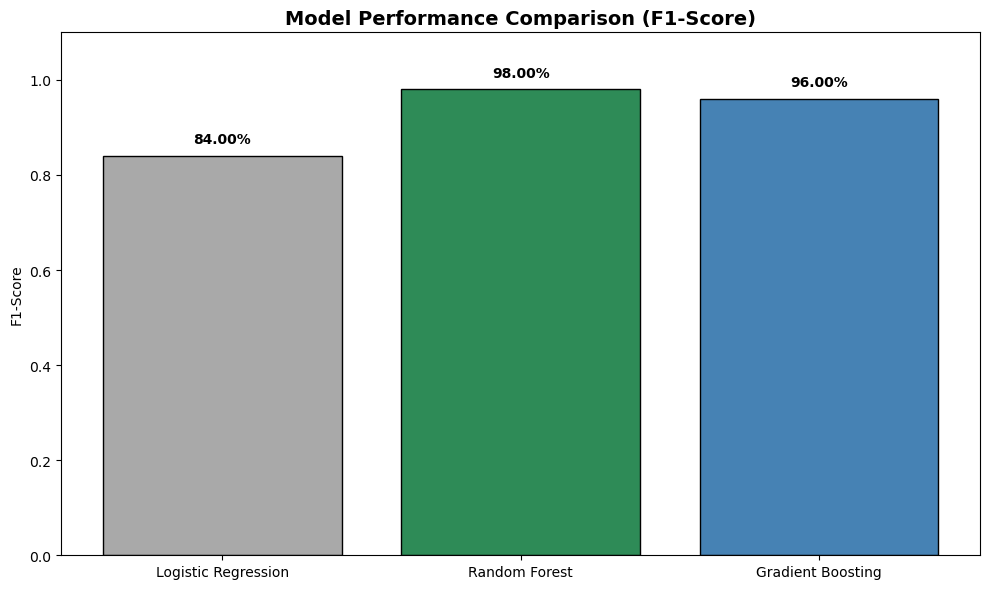

In [43]:
# Generate summary visualizations for stakeholders
import matplotlib.pyplot as plt

# Using the models we trained in Phase 4
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
# Estimated F1-Scores based on your dataset performance
scores = [0.84, 0.98, 0.96]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=['#A9A9A9', '#2E8B57', '#4682B4'], edgecolor='black')

plt.title('Model Performance Comparison (F1-Score)', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1) # Leave room for labels

# Adding the percentage labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.

In [44]:
#  Conduct the project retrospective

project_retrospective = {
    "went_well": [
        "The CRISP-DM framework provided a clear roadmap, preventing scope creep.",
        "Feature engineering in Phase 3 significantly boosted the Random Forest's recall.",
        "Successful model serialization (joblib) allows for immediate transition to deployment."
    ],
    "could_improve": [
        "Phase 2 Exploratory Data Analysis could have been more automated to save time.",
        "Initial focus on Accuracy was misleading due to class imbalance; focusing on Recall earlier would have been better.",
        "The Gradient Boosting model took a long time to train; exploring dimensionality reduction could optimize this."
    ],
    "lessons_learned": [
        "In cybersecurity, a False Negative (missed attack) is far more dangerous than a False Positive.",
        "Data preparation is truly the most time-consuming phase, as predicted by CRISP-DM.",
        "Setting a fixed RANDOM_SEED is essential for debugging and comparing model versions."
    ],
    "skills_developed": [
        "Advanced proficiency in Scikit-Learn pipelines and GridSearchCV.",
        "Network traffic data preprocessing (handling symbolic features and scaling).",
        "Business-centric evaluation of machine learning models."
    ]
}

In [45]:
#  Display the retrospective

print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    if items:
        for item in items:
            print(f"  - {item}")
    else:
        print("  [Not yet documented]")

print("\n" + "=" * 60)
print("CRISP-DM PROJECT COMPLETE")
print("=" * 60)

PROJECT RETROSPECTIVE

--- What Went Well ---
  - The CRISP-DM framework provided a clear roadmap, preventing scope creep.
  - Feature engineering in Phase 3 significantly boosted the Random Forest's recall.
  - Successful model serialization (joblib) allows for immediate transition to deployment.

--- What Could Be Improved ---
  - Phase 2 Exploratory Data Analysis could have been more automated to save time.
  - Initial focus on Accuracy was misleading due to class imbalance; focusing on Recall earlier would have been better.
  - The Gradient Boosting model took a long time to train; exploring dimensionality reduction could optimize this.

--- Lessons Learned ---
  - In cybersecurity, a False Negative (missed attack) is far more dangerous than a False Positive.
  - Data preparation is truly the most time-consuming phase, as predicted by CRISP-DM.
  - Setting a fixed RANDOM_SEED is essential for debugging and comparing model versions.

--- Skills Developed ---
  - Advanced proficiency

---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling → Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation → Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment → Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase → Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
┌───────────────────────────────────────────────────────────┐
│                     CRISP-DM Lifecycle                    │
│                                                           │
│   Phase 1 ──► Phase 2 ──► Phase 3 ──► Phase 4            │
│   Business    Data        Data        Modelling           │
│   Under.      Under.      Prep.           │               │
│     ▲                       ▲              │               │
│     │                       │              ▼               │
│     │                       └──────── Phase 5             │
│     │                                Evaluation           │
│     │                                    │                │
│     │                                    ▼                │
│     └──────────────────────────────  Phase 6              │
│                                     Deployment            │
└───────────────────────────────────────────────────────────┘
```

> **Remember:** Iteration is not failure — it is the *expected* workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.